## Ejercicio de Programación 3 - RFI sobre visibilidades reales

1. Implementar diferentes tipos de RFI según las fórmulas
2. Aplicar RFI a las visibilidades simuladas
3. Analizar el impacto en amplitud y fase
4. Visualizar la distribución de RFI en el plano UV
5. Calcular estadísticas de contaminación



In [2]:
%reload_ext autoreload
%autoreload 2

In [3]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# imports
from numba import cuda
import math
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
# modules
from modules.simulation import visibilities_simulation
from modules.plots import plot_uv_coverage, plot_uv_coverage_2


/home/vcnt/y/envs/radiointerferometry-env/lib/python3.13/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


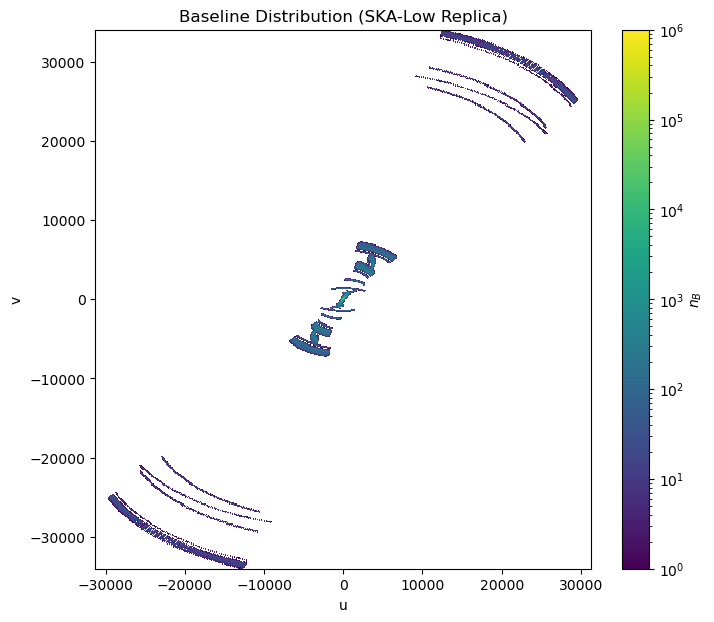

In [4]:
# simulate visibilities no grid
SKA_LOW_AA1 = {
    "latitude": -26.696, 
    "longitude": 116.637,
    "file_route": "../antenna_arrays/ska_low_AA2.cfg",
    "ra-dec": [0, -30],
    "utc_start": "2023-11-21T03:00:00",
    "utc_end": "2023-11-21T06:00:00",
    "step_min": 2,
    "n_freqs": 1500,
    'bandwidth': None, # Mhz   
    "interferometer": {
        "name": "SKA_LOW", 
        "band_name": "BAND" 
    },
    "n_sources": 1,
    "max_offset_deg": 1.0, 
    "flux_range": [0.1, 2.0],
    "seed": 42
}

V, uvw, uvw_lambda, [frequencies, channel_bandwidth], baselines_enu, _ , _ , times_sec = visibilities_simulation(SKA_LOW_AA1)

# plot_uv_coverage(uvw, unit='km')
plot_uv_coverage_2(uvw, 512)

In [5]:
print("uvw shape: ", uvw.shape)
print("V shape: ", V.shape)
print("V baselines shape: ", V[0].shape)
print("Primeros 3 registros del baseline 0: \n", V[0][:3])   

uvw shape:  (2016, 91, 3)
V shape:  (2016, 91, 1500)
V baselines shape:  (91, 1500)
Primeros 3 registros del baseline 0: 
 [[1.6651078 -0.3723363j  1.6647793 -0.37380236j 1.6644495 -0.37526816j
  ... 0.05563721-1.7053219j  0.05413556-1.7053703j
  0.05263387-1.7054173j ]
 [1.6661096 -0.36782768j 1.665789  -0.36927658j 1.6654673 -0.3707252j
  ... 0.08790118-1.7039635j  0.08641918-1.7040393j
  0.08493711-1.7041138j ]
 [1.6671053 -0.36328796j 1.6667928 -0.36471954j 1.6664789 -0.3661509j
  ... 0.12033656-1.7019805j  0.11887483-1.7020832j
  0.11741301-1.7021847j ]]


Inyección de RFI

In [6]:
from modules.noise import narrowband_rfi, broadband_rfi, transient_rfi

V_rfi, k, f_rfi = narrowband_rfi(
    V,
    frequencies,
    amplitude=(0, 10),
    k_rfi=[10, 90, 175, 210, 97, 14, 15, 26, 431, 708, 900],
    duty_cycle=0.6,
)


V_rfi_bb, k_bb, f_rfi_bb = broadband_rfi(
    V,
    frequencies,
    amplitude=(0, 10),
    k_range=(300,378),
    duty_cycle=0.1
)

V_rfi_t, k_t = transient_rfi(
    V,
    times=times_sec,
    amplitude=10,
    n_step=[10, 50, 75],
    duration_steps=1,
    # t_rfi=3600
)

print("Canal RFI:", k)
print("Frecuencia [MHz]:", f_rfi / 1e6)


V_corrupted = V + V_rfi + V_rfi_bb + V_rfi_t

Canal RFI: [ 10  90 175 210  97  14  15  26 431 708 900]
Frecuencia [MHz]: [ 52.00133422  68.01200801  85.0233489   92.02801868  69.41294196
  52.80186791  53.00200133  55.20346898 136.257505   191.69446298
 230.12008005]


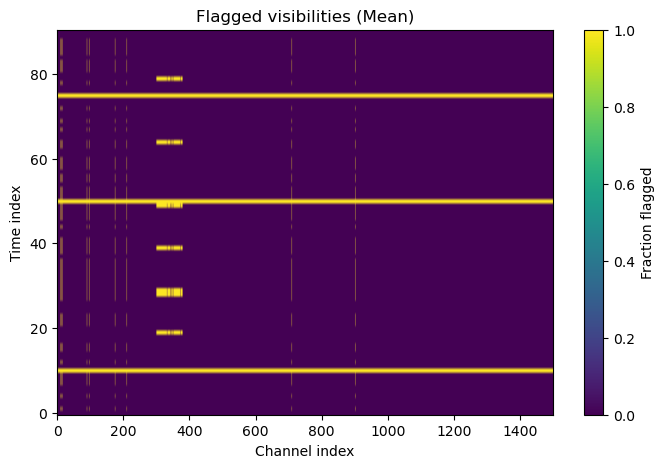

In [ ]:
from modules.plots import plot_flag_map

true_mask = np.abs(V_rfi + V_rfi_bb + V_rfi_t)
plot_flag_map(true_mask, mode='mean')

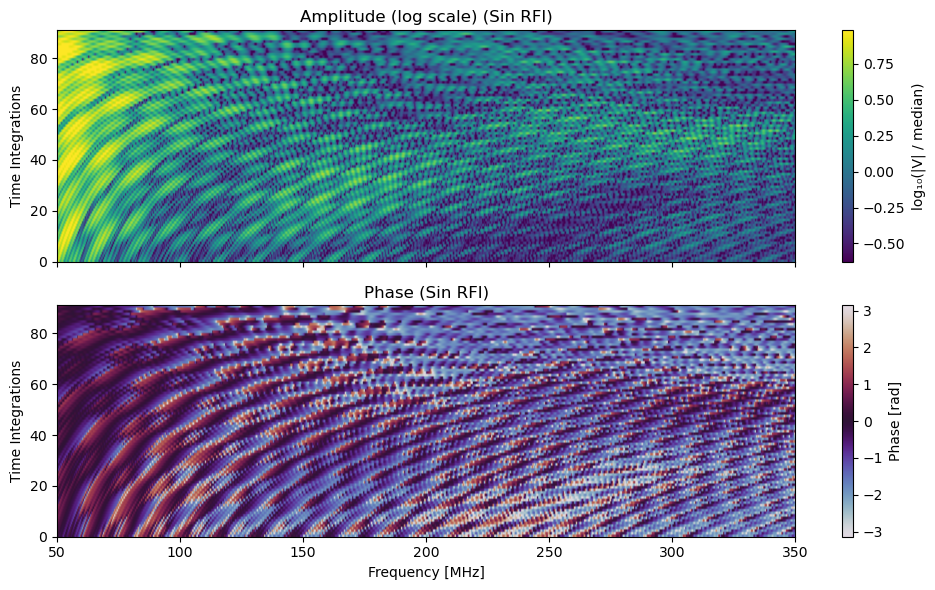

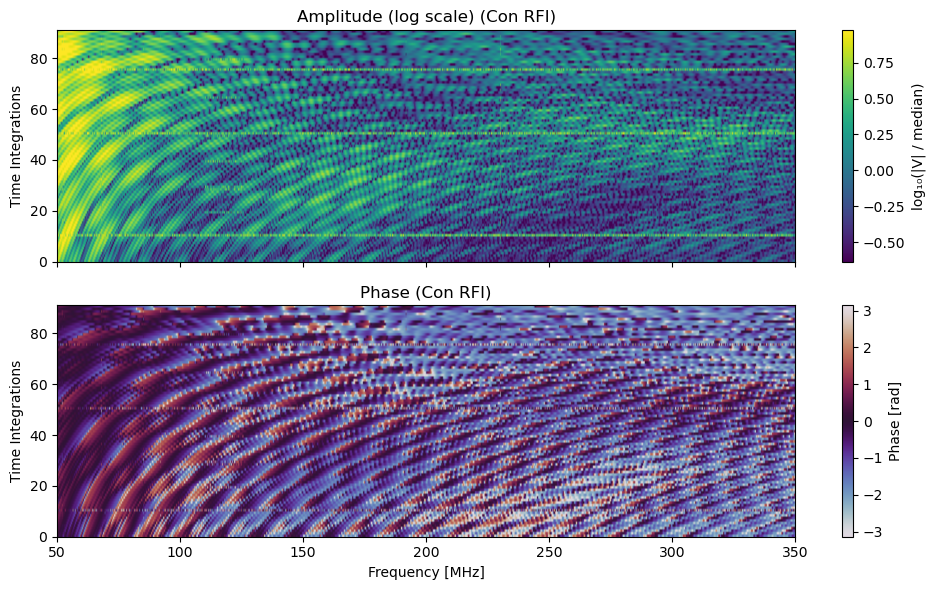

In [7]:
from modules.plots import plot_time_frequency

plot_time_frequency(
    V,
    frequencies,
    title_suffix="(Sin RFI)"
)

plot_time_frequency(
    V_corrupted,
    frequencies,
    title_suffix="(Con RFI)"
)

In [7]:
V_corrupted.shape

(2016, 91, 1500)

## Algortimos de Flagging

### 1. SumTreshold

In [ ]:
from modules.flagging import sumthreshold_frequency, calculate_rfi_metrics

flags_st = sumthreshold_frequency(V_corrupted, k=3, window_sizes=(1,2))

In [9]:
# mask
V_flagged_st = V_corrupted.copy()

V_flagged_st[flags_st] = np.nan

print("Fracción de datos flaggeados:",
      flags_st.mean())

Fracción de datos flaggeados: 0.5139515342461771


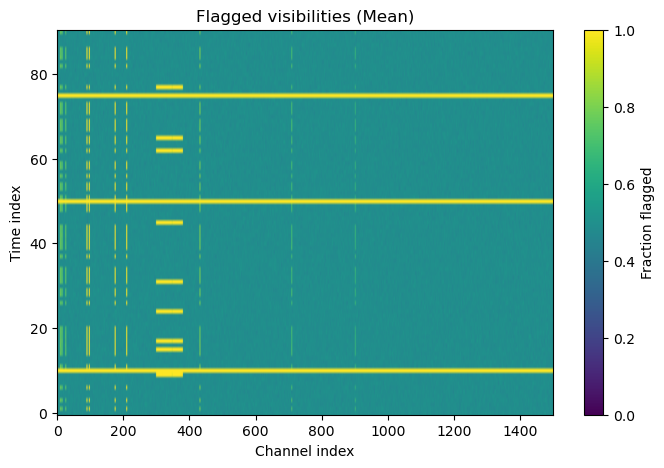

In [10]:
from modules.plots import plot_flag_map

plot_flag_map(flags_st, mode='mean')

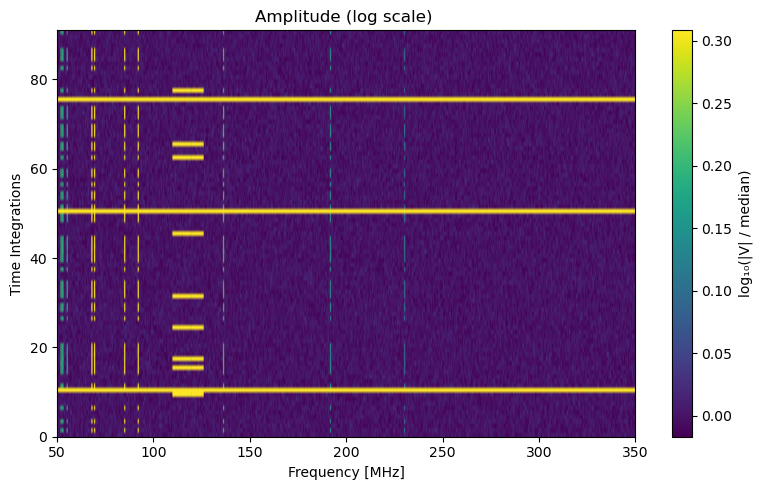

In [11]:
plot_time_frequency(V=flags_st, frequencies=frequencies, show_phase=False, figsize=(8,5))

## 2. Umbral estadístico

In [12]:
from modules.flagging import statistical_threshold

flags_stat = statistical_threshold(V_corrupted, k=1)

In [13]:
# mask
V_flagged_stat = V_corrupted.copy()
V_flagged_stat[flags_stat] = np.nan

print("Fracción de datos flaggeados:",
      flags_stat.mean())

Fracción de datos flaggeados: 0.030724224518867378


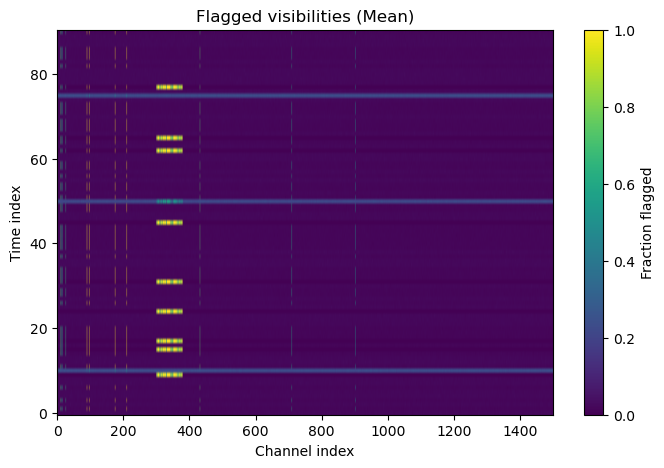

In [14]:
plot_flag_map(flags_stat, mode='mean')

## 3. Flaggin por variación de amplitud

In [21]:
from modules.flagging import amplitude_variation_flagging

u = uvw_lambda[...,0]
v = uvw_lambda[...,1]

flags_amp = amplitude_variation_flagging(V_corrupted, u, v)

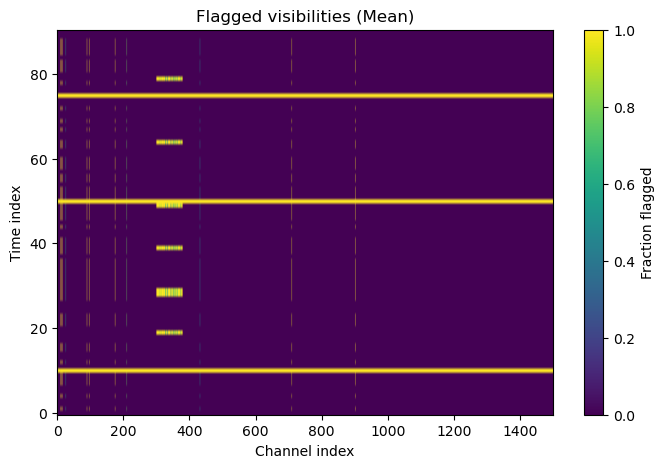

In [22]:
from modules.plots import plot_flag_map

plot_flag_map(flags_amp, mode='mean')

## 4. Flagging por coherencia de Fase

In [ ]:
from modules.flagging import phase_coherence_flagging

mask_c = phase_coherence_flagging(V_corrupted, w=8)

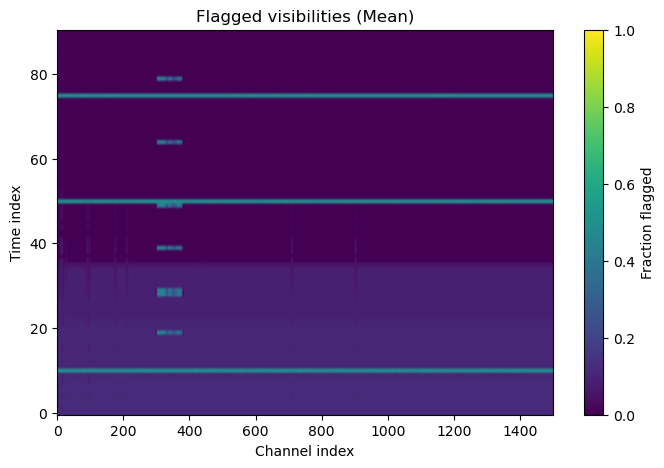

In [11]:
from modules.plots import plot_flag_map

plot_flag_map(mask_c, mode='mean')